# Experiments Guide

## 0. Colab Setup

In [ ]:
!git clone -b dev https://github.com/luigiaceto/explainable-models-for-speech-analysis.git
%cd explainable-models-for-speech-analysis
%pip install -r requirements-colab.txt

## 1. Project Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "crema_d"
AUDIO_DIR = RAW_DIR / "AudioWAV"
FEATURE_DIR = DATA_DIR / "features" / "wav2vec2_base_mean_std"
BLACK_BOX_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "blackbox"
BLACK_BOX_REPORT_DIR = PROJECT_ROOT / "reports" / "blackbox"

FEATURE_EXTRACTION_BATCH_SIZE = 8
RANDOM_STATE = 42

PROJECT_ROOT

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis')

## 2. Download CREMA-D

In [ ]:
from src.preprocessing.download_crema_d import download_crema_d

metadata = download_crema_d(
    output_dir=RAW_DIR,
    overwrite=False
)

metadata.head(n=10)

,file_name,actor_id,sentence_code,sentence,emotion_code,emotion,label,intensity_code,intensity,audio_path
0,1001_DFA_ANG_XX.wav,1001,DFA,Don't forget a jacket,ANG,anger,0,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
1,1001_DFA_DIS_XX.wav,1001,DFA,Don't forget a jacket,DIS,disgust,1,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
2,1001_DFA_FEA_XX.wav,1001,DFA,Don't forget a jacket,FEA,fear,2,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
3,1001_DFA_HAP_XX.wav,1001,DFA,Don't forget a jacket,HAP,happy,3,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
4,1001_DFA_NEU_XX.wav,1001,DFA,Don't forget a jacket,NEU,neutral,4,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
5,1001_DFA_SAD_XX.wav,1001,DFA,Don't forget a jacket,SAD,sad,5,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
6,1001_IEO_ANG_HI.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,HI,high,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
7,1001_IEO_ANG_LO.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,LO,low,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
8,1001_IEO_ANG_MD.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,MD,medium,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
9,1001_IEO_DIS_HI.wav,1001,IEO,It's eleven o'clock,DIS,disgust,1,HI,high,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...


## 3. Dataset Statistics

In [3]:
from src.data.crema_d import print_dataset_statistics

print_dataset_statistics(metadata)

Total samples: 7442
Actors: 91
Sentence prompts: 12

Samples per emotion:
emotion  sample_count  percentage
  anger          1271   17.078742
disgust          1271   17.078742
   fear          1271   17.078742
  happy          1271   17.078742
neutral          1087   14.606289
    sad          1271   17.078742


## 4. Extract Frozen wav2vec2 Features

In [4]:
from src.preprocessing.extract_wav2vec_features import extract_wav2vec_features

feature_paths = extract_wav2vec_features(
    metadata_csv=RAW_DIR / "metadata.csv",
    audio_dir=AUDIO_DIR,
    output_dir=FEATURE_DIR,
    batch_size=FEATURE_EXTRACTION_BATCH_SIZE,
    overwrite=False,
)

feature_paths

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/wav2vec2_base_mean_std/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/wav2vec2_base_mean_std/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/wav2vec2_base_mean_std/feature_config.json')}

## 5. Train the Black-Box Classifier

In [5]:
from src.training.train_blackbox import TrainingConfig, train_blackbox

TRAINING_BATCH_SIZE = 64
TRAINING_EPOCHS = 100

training_config = TrainingConfig(
    batch_size=TRAINING_BATCH_SIZE,
    epochs=TRAINING_EPOCHS,
    learning_rate=2e-4,
    weight_decay=1e-4,
    early_stopping_patience=10,
    random_state=RANDOM_STATE
)

training_results = train_blackbox(
    feature_dir=FEATURE_DIR,
    output_dir=BLACK_BOX_CHECKPOINT_DIR,
    config=training_config,
)

Training black-box model:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | train loss 1.5270, acc 0.3768, macro F1 0.3512 | val loss 1.3570, acc 0.4677, macro F1 0.4285, weighted F1 0.4263 | best
Epoch 002 | train loss 1.3598, acc 0.4544, macro F1 0.4428 | val loss 1.2569, acc 0.5090, macro F1 0.4974, weighted F1 0.4964 | best
Epoch 003 | train loss 1.2993, acc 0.4828, macro F1 0.4771 | val loss 1.2317, acc 0.5134, macro F1 0.5031, weighted F1 0.5019 | best
Epoch 004 | train loss 1.2434, acc 0.5133, macro F1 0.5091 | val loss 1.2380, acc 0.5081, macro F1 0.5024, weighted F1 0.5007 | patience 1/10
Epoch 005 | train loss 1.2188, acc 0.5176, macro F1 0.5152 | val loss 1.2095, acc 0.5332, macro F1 0.5196, weighted F1 0.5182 | best
Epoch 006 | train loss 1.1959, acc 0.5360, macro F1 0.5333 | val loss 1.1676, acc 0.5475, macro F1 0.5367, weighted F1 0.5350 | best
Epoch 007 | train loss 1.1697, acc 0.5435, macro F1 0.5406 | val loss 1.1636, acc 0.5475, macro F1 0.5417, weighted F1 0.5402 | best
Epoch 008 | train loss 1.1550, acc 0.5477, macro F1 0.5455 |

## 6. Evaluate the Black-Box Classifier

In [ ]:
from src.evaluation.evaluate_blackbox import evaluate_blackbox, print_classification_metrics

test_metrics = evaluate_blackbox(
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test",
    output_dir=BLACK_BOX_REPORT_DIR
)

print_classification_metrics(test_metrics)

Accuracy:    0.6526
Macro F1:    0.6508
Weighted F1: 0.6489

Classification report:
emotion precision recall f1_score  support
  anger    0.7336 0.8220   0.7753      191
disgust    0.6307 0.5812   0.6049      191
   fear    0.5803 0.5895   0.5849      190
  happy    0.6689 0.5183   0.5841      191
neutral    0.6754 0.7914   0.7288      163
    sad    0.6205 0.6335   0.6269      191


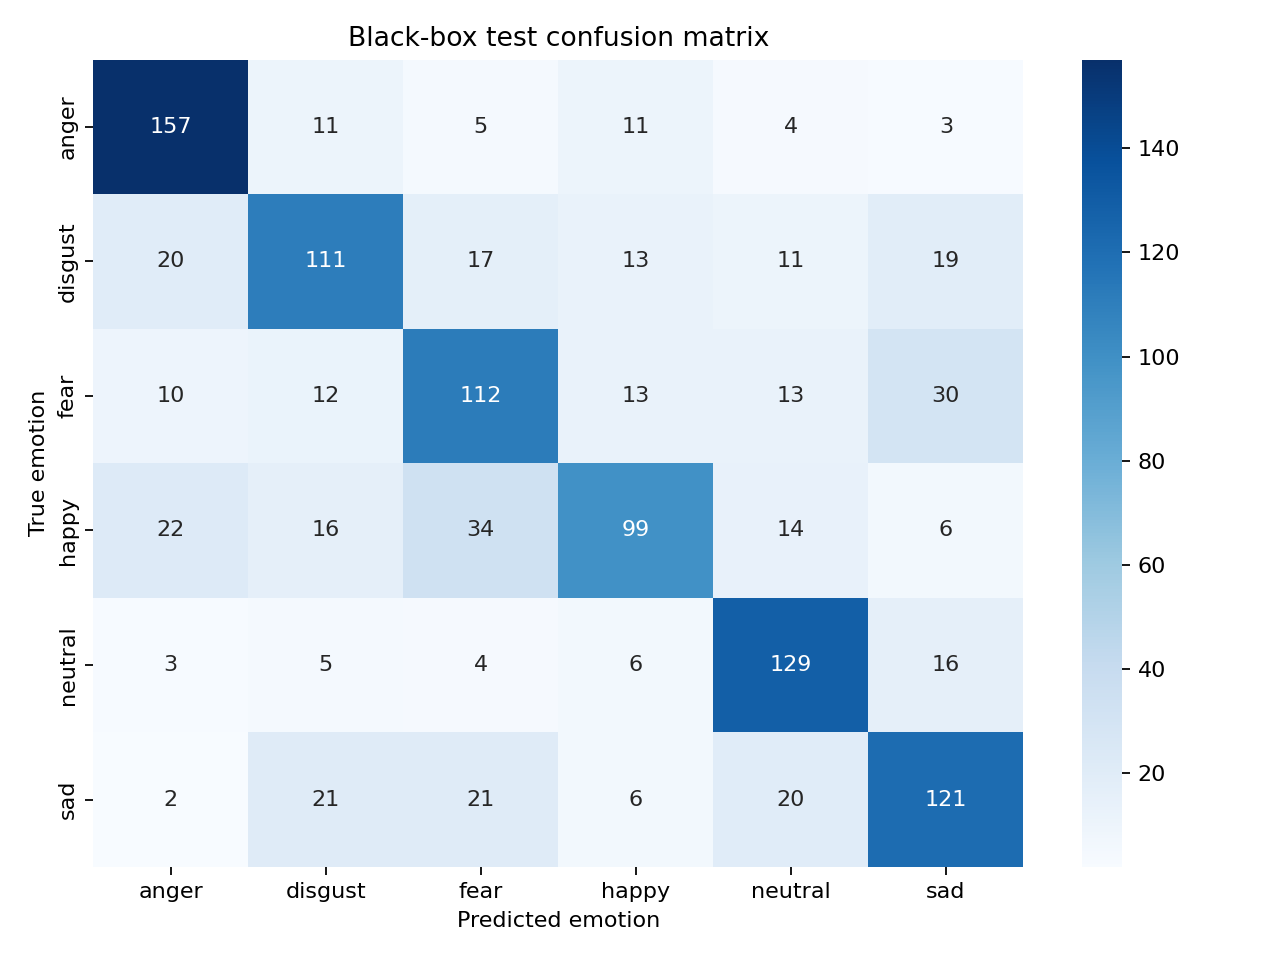

In [ ]:
from IPython.display import Image, display

confusion_matrix_path = BLACK_BOX_REPORT_DIR / "test_confusion_matrix.png"
if confusion_matrix_path.exists():
    display(Image(filename=str(confusion_matrix_path)))